In [1]:
# ==========================================
# Diabetes Risk Classification System
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("diabetes.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print("Dataset Shape :", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape : (768, 9)

Column Names:

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values

In [4]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("New Dataset Shape :", df.shape)

Duplicate Records : 0
New Dataset Shape : (768, 9)


In [5]:
# ==========================================
# Dataset Statistics
# ==========================================

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# ==========================================
# Feature Selection
# ==========================================

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (768, 8)
Target Shape : (768,)


In [7]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 614
Testing Samples : 154


In [8]:
# ==========================================
# Random Forest Model
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [9]:
# ==========================================
# Make Predictions
# ==========================================

y_pred = model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [10]:
# ==========================================
# Accuracy Score
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score : {:.2f}%".format(accuracy * 100))

Accuracy Score : 72.08%


In [11]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[77 22]
 [21 34]]


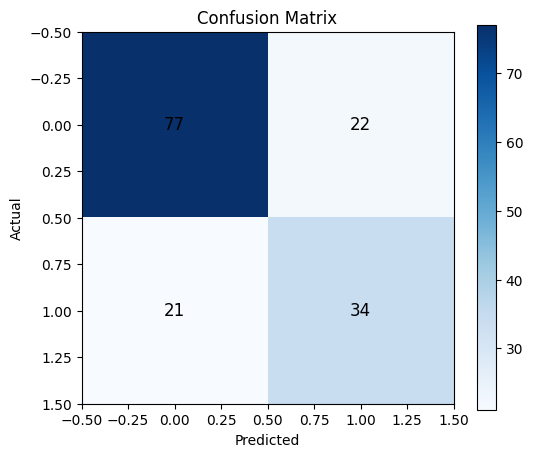

In [12]:
# ==========================================
# Plot Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j],
                 ha="center",
                 va="center",
                 fontsize=12)

plt.show()

In [13]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [14]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
1                   Glucose    0.258864
5                       BMI    0.169984
7                       Age    0.140931
6  DiabetesPedigreeFunction    0.123768
2             BloodPressure    0.088134
0               Pregnancies    0.076551
4                   Insulin    0.076122
3             SkinThickness    0.065646


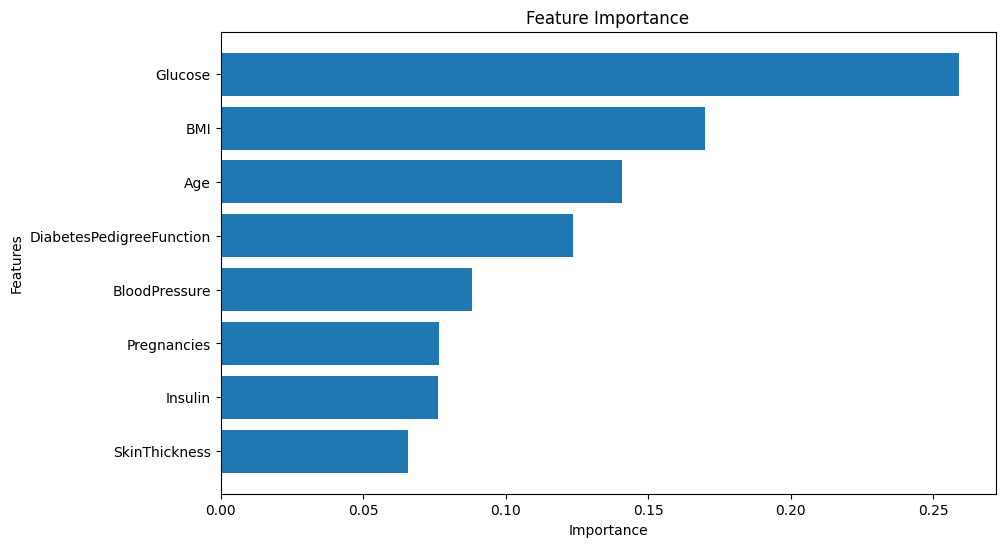

In [15]:
# ==========================================
# Feature Importance Graph
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [16]:
# ==========================================
# Predict New Patient
# ==========================================

sample = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 95,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 85,
    "BMI": 24.5,
    "DiabetesPedigreeFunction": 0.25,
    "Age": 30
}])

prediction = model.predict(sample)

if prediction[0] == 0:
    print("🟢 NO DIABETES DETECTED")
else:
    print("🔴 DIABETES RISK DETECTED")

🟢 NO DIABETES DETECTED
